
# Project 3 (20%)
## LSTM Models for Sequence Modeling

### Learning Objectives
By completing this project, you will be able to:
- Understand the limitations of vanilla RNNs.
- Implement and train an LSTM in PyTorch.
- Apply sequence models to a real-world sequential prediction task.
- Analyze LSTM behavior through experiments and comparisons.

### Selected Task
For **Part 2 - Option B**, I implement a **time-series forecasting** model that predicts the **Bitcoin daily closing price** from historical data in `BTC-USD_daily.csv`.

### Problem Definition
- **Input**: a rolling window of previous daily close prices.
- **Target**: the next `forecast_horizon` days of close prices.
- **Main hyperparameters**: `sequence_length`, `forecast_horizon`, hidden size, number of LSTM layers, dropout, learning rate, and number of training epochs.
- **Output visualization**: the notebook ends with a plot of the **last 30 real days** and the **future predicted prices** appended to them.



## Part 1 - Conceptual Questions (4%)

### 1. Why do standard RNNs struggle with long sequences?
Standard RNNs repeatedly multiply hidden states through time, so gradients can **vanish** or **explode** during backpropagation. As a result, they usually fail to preserve useful information from much earlier time steps and become unstable on long sequences.

### 2. What problem does the cell state in an LSTM solve?
The LSTM cell state creates a more direct path for information to flow across many time steps. This reduces the vanishing-gradient problem and helps the model keep long-range context that a vanilla RNN would often forget.

### 3. What are the roles of the input, forget, and output gates?
- **Forget gate** decides what older information should be removed from the cell state.
- **Input gate** decides what new information should be written into the cell state.
- **Output gate** decides which part of the internal state should be exposed as the hidden state for the current time step.

Together, these gates let the LSTM selectively remember, update, and expose information instead of overwriting everything at every step.

### 4. Why might LSTMs outperform vanilla RNNs on time-series or text?
LSTMs are better at modeling **longer temporal dependencies**, handling noisy sequential patterns, and learning when to remember or forget information. In tasks like text and financial time series, these abilities usually produce more stable training and stronger predictive performance than vanilla RNNs.



## Part 2 - Dataset Preparation (3%)

### Chosen Setting
I chose **Option B: Time-Series Prediction**.

### Dataset
The dataset is `BTC-USD_daily.csv`, which contains daily Bitcoin market data. I use only the **`close`** column as the forecasting target because the project requirement is to predict the closing price.

### Preprocessing Plan
1. Sort the data chronologically by date.
2. Keep the `date` column for plotting and use `close` as the numeric signal.
3. Split the series in **time order** into train/validation/test segments.
4. Fit a scaler on the **training portion only** to avoid data leakage.
5. Convert the series into supervised sequences:
   - input window length = `sequence_length`
   - output window length = `forecast_horizon`

### Why this setup is appropriate
This is a natural sequence-learning task because future prices depend on historical temporal patterns. An LSTM is a suitable model because it can summarize recent context in a hidden state and produce a multi-step forecast.


In [1]:

import copy
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')
print(f'Using device: {device}')


Using device: cpu



### Dataset Summary
The following cell loads the Bitcoin dataset, checks its quality, creates chronological train/validation/test splits, and transforms the daily close prices into input-output windows for multi-step forecasting.


In [2]:

# Core forecasting hyperparameters
sequence_length = 60
forecast_horizon = 7
batch_size = 64

# Load and prepare the dataset
btc = pd.read_csv('BTC-USD_daily.csv')
btc['date'] = pd.to_datetime(btc['date'])
btc = btc.sort_values('date').reset_index(drop=True)

series = btc['close'].astype(np.float32).values.reshape(-1, 1)
dates = btc['date']

print('Date range:', dates.min().date(), 'to', dates.max().date())
print('Number of rows:', len(btc))
print('Missing values by column:')
print(btc.isna().sum())
print('\nFirst 5 rows:')
print(btc[['date', 'close']].head())

train_end = int(len(series) * 0.70)
val_end = int(len(series) * 0.85)

scaler = MinMaxScaler()
scaler.fit(series[:train_end])
scaled_series = scaler.transform(series).astype(np.float32)


def build_windows(values, target_dates, seq_len, horizon, train_stop, val_stop):
    X, y, input_end_dates, forecast_start_dates, forecast_end_dates = [], [], [], [], []
    split_tags = []

    for start in range(len(values) - seq_len - horizon + 1):
        end_input = start + seq_len
        end_target = end_input + horizon

        X.append(values[start:end_input])
        y.append(values[end_input:end_target].reshape(-1))
        input_end_dates.append(target_dates.iloc[end_input - 1])
        forecast_start_dates.append(target_dates.iloc[end_input])
        forecast_end_dates.append(target_dates.iloc[end_target - 1])

        if end_target <= train_stop:
            split_tags.append('train')
        elif end_target <= val_stop:
            split_tags.append('val')
        else:
            split_tags.append('test')

    return {
        'X': np.array(X, dtype=np.float32),
        'y': np.array(y, dtype=np.float32),
        'input_end_dates': np.array(input_end_dates),
        'forecast_start_dates': np.array(forecast_start_dates),
        'forecast_end_dates': np.array(forecast_end_dates),
        'split': np.array(split_tags),
    }


window_data = build_windows(
    values=scaled_series,
    target_dates=dates,
    seq_len=sequence_length,
    horizon=forecast_horizon,
    train_stop=train_end,
    val_stop=val_end,
)

train_mask = window_data['split'] == 'train'
val_mask = window_data['split'] == 'val'
test_mask = window_data['split'] == 'test'

print('\nWindow counts:')
print({
    'train': int(train_mask.sum()),
    'val': int(val_mask.sum()),
    'test': int(test_mask.sum()),
})

sample_idx = np.where(train_mask)[0][0]
print('\nExample input window shape:', window_data['X'][sample_idx].shape)
print('Example target horizon shape:', window_data['y'][sample_idx].shape)
print('Input window last date:', window_data['input_end_dates'][sample_idx])
print('Forecast starts on:', window_data['forecast_start_dates'][sample_idx])
print('Forecast ends on:', window_data['forecast_end_dates'][sample_idx])
print('First 5 scaled input values:', window_data['X'][sample_idx][:5].flatten())
print('Forecast target values:', window_data['y'][sample_idx])


Date range: 2014-09-17 to 2026-02-27
Number of rows: 4182
Missing values by column:
date      0
open      0
high      0
low       0
close     0
volume    0
ticker    0
dtype: int64

First 5 rows:
        date       close
0 2014-09-17  457.334015
1 2014-09-18  424.440002
2 2014-09-19  394.795990
3 2014-09-20  408.903992
4 2014-09-21  398.821014

Window counts:
{'train': 2861, 'val': 627, 'test': 628}

Example input window shape: (60, 1)
Example target horizon shape: (7,)
Input window last date: 2014-11-15 00:00:00
Forecast starts on: 2014-11-16 00:00:00
Forecast ends on: 2014-11-22 00:00:00
First 5 scaled input values: [0.00414359 0.00365546 0.00321557 0.00342492 0.0032753 ]
Forecast target values: [0.00311297 0.00310593 0.00292475 0.00300424 0.00266717 0.00256341
 0.00259416]



## Part 3 - LSTM Model Implementation (6%)

### Design Choices
- I use a **many-to-many regression** setup where the model reads `sequence_length` past close prices and predicts the next `forecast_horizon` close prices in one forward pass.
- Because the input is a numeric time series instead of text, there is **no embedding layer**. Each time step is represented by one feature: the scaled close price.
- The LSTM output at the final time step summarizes the full input window and is passed to a linear layer that produces the multi-step forecast vector.

### Tensor Shapes
- Input to model: `(batch_size, sequence_length, 1)`
- LSTM output: `(batch_size, sequence_length, hidden_size)`
- Final hidden summary used for regression: `(batch_size, hidden_size)`
- Final prediction: `(batch_size, forecast_horizon)`


In [3]:

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, horizon=7):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=effective_dropout,
            batch_first=True,
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, horizon),
        )

    def forward(self, x):
        # x shape: (batch, sequence_length, 1)
        outputs, _ = self.lstm(x)
        # last_hidden shape: (batch, hidden_size)
        last_hidden = outputs[:, -1, :]
        # predictions shape: (batch, forecast_horizon)
        return self.regressor(last_hidden)


class MLPForecaster(nn.Module):
    def __init__(self, sequence_length, horizon, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(sequence_length, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, horizon),
        )

    def forward(self, x):
        return self.net(x)


@dataclass
class TrainingConfig:
    hidden_size: int = 64
    num_layers: int = 2
    dropout: float = 0.2
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    epochs: int = 35
    patience: int = 8


def create_loaders(seq_len, horizon, batch_size=64):
    local_window_data = build_windows(
        values=scaled_series,
        target_dates=dates,
        seq_len=seq_len,
        horizon=horizon,
        train_stop=train_end,
        val_stop=val_end,
    )

    local_masks = {
        'train': local_window_data['split'] == 'train',
        'val': local_window_data['split'] == 'val',
        'test': local_window_data['split'] == 'test',
    }

    datasets = {
        split: SequenceDataset(local_window_data['X'][mask], local_window_data['y'][mask])
        for split, mask in local_masks.items()
    }

    loaders = {
        'train': DataLoader(datasets['train'], batch_size=batch_size, shuffle=True),
        'val': DataLoader(datasets['val'], batch_size=batch_size, shuffle=False),
        'test': DataLoader(datasets['test'], batch_size=batch_size, shuffle=False),
    }
    return local_window_data, local_masks, datasets, loaders


def inverse_close(values_2d):
    return scaler.inverse_transform(values_2d.reshape(-1, 1)).reshape(values_2d.shape)


def evaluate_model(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    predictions, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            total_loss += loss.item() * len(X_batch)
            predictions.append(preds.cpu().numpy())
            targets.append(y_batch.cpu().numpy())

    predictions = np.vstack(predictions)
    targets = np.vstack(targets)
    avg_loss = total_loss / len(loader.dataset)

    pred_original = inverse_close(predictions)
    target_original = inverse_close(targets)

    rmse = math.sqrt(mean_squared_error(target_original.flatten(), pred_original.flatten()))
    mae = mean_absolute_error(target_original.flatten(), pred_original.flatten())
    mape = mean_absolute_percentage_error(target_original.flatten(), pred_original.flatten()) * 100

    return {
        'loss': avg_loss,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'predictions': pred_original,
        'targets': target_original,
    }


def train_model(model, loaders, config):
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
    )

    history = {'train_loss': [], 'val_loss': []}
    best_state = None
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, config.epochs + 1):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in loaders['train']:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * len(X_batch)

        train_loss = running_loss / len(loaders['train'].dataset)
        val_metrics = evaluate_model(model, loaders['val'], loss_fn)
        val_loss = val_metrics['loss']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | "
                f"val_loss={val_loss:.6f} | val_rmse={val_metrics['rmse']:.2f}"
            )

        if patience_counter >= config.patience:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

    model.load_state_dict(best_state)
    return history



## Part 4 - Training and Evaluation (3%)

I train the LSTM using mean squared error on the scaled targets and report performance on validation and test sets using **RMSE**, **MAE**, and **MAPE** in the original price scale. Because this is a regression task, these metrics are more informative than classification accuracy.


Epoch 01 | train_loss=0.065139 | val_loss=0.041324 | val_rmse=13698.94
Epoch 05 | train_loss=0.001544 | val_loss=0.002189 | val_rmse=3153.22
Epoch 10 | train_loss=0.001216 | val_loss=0.002045 | val_rmse=3047.42
Epoch 15 | train_loss=0.001154 | val_loss=0.002687 | val_rmse=3493.24
Epoch 20 | train_loss=0.000999 | val_loss=0.001980 | val_rmse=2998.95
Early stopping triggered at epoch 21.
Main LSTM results:


,split,rmse,mae,mape_percent
0,validation,2624.621,1802.100,5.128
1,test,16937.862,14016.049,14.090


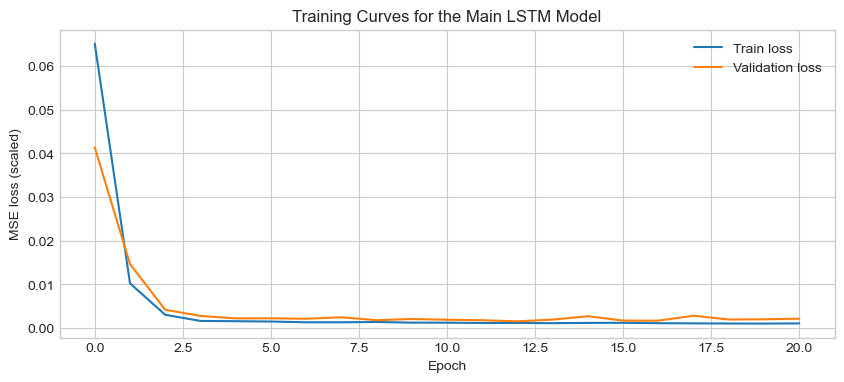

In [4]:

training_config = TrainingConfig(
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    learning_rate=1e-3,
    weight_decay=1e-5,
    epochs=35,
    patience=8,
)

window_data, masks, datasets, loaders = create_loaders(
    seq_len=sequence_length,
    horizon=forecast_horizon,
    batch_size=batch_size,
)

main_lstm = LSTMForecaster(
    input_size=1,
    hidden_size=training_config.hidden_size,
    num_layers=training_config.num_layers,
    dropout=training_config.dropout,
    horizon=forecast_horizon,
).to(device)

history = train_model(main_lstm, loaders, training_config)
loss_fn = nn.MSELoss()
val_metrics = evaluate_model(main_lstm, loaders['val'], loss_fn)
test_metrics = evaluate_model(main_lstm, loaders['test'], loss_fn)

metrics_table = pd.DataFrame([
    {
        'split': 'validation',
        'rmse': val_metrics['rmse'],
        'mae': val_metrics['mae'],
        'mape_percent': val_metrics['mape'],
    },
    {
        'split': 'test',
        'rmse': test_metrics['rmse'],
        'mae': test_metrics['mae'],
        'mape_percent': test_metrics['mape'],
    },
])

print('Main LSTM results:')
display(metrics_table.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train loss')
ax.plot(history['val_loss'], label='Validation loss')
ax.set_title('Training Curves for the Main LSTM Model')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss (scaled)')
ax.legend()
plt.show()



## Part 5 - Controlled Experiment (2%)

### Experiment Choice
I vary **sequence length** while keeping the rest of the training setup fixed.

### Motivation
A short history may miss medium-term structure, but an overly long history can make optimization harder and may include stale information. This experiment checks whether giving the LSTM a longer memory window improves forecasting quality.


In [8]:

def run_lstm_experiment(seq_len, horizon, config, batch_size=64):
    local_window_data, local_masks, local_datasets, local_loaders = create_loaders(
        seq_len=seq_len,
        horizon=horizon,
        batch_size=batch_size,
    )

    model = LSTMForecaster(
        input_size=1,
        hidden_size=config.hidden_size,
        num_layers=config.num_layers,
        dropout=config.dropout,
        horizon=horizon,
    ).to(device)

    history = train_model(model, local_loaders, config)
    loss_fn = nn.MSELoss()
    val_result = evaluate_model(model, local_loaders['val'], loss_fn)
    test_result = evaluate_model(model, local_loaders['test'], loss_fn)

    return {
        'sequence_length': seq_len,
        'val_rmse': val_result['rmse'],
        'test_rmse': test_result['rmse'],
        'val_mae': val_result['mae'],
        'test_mae': test_result['mae'],
        'epochs_ran': len(history['train_loss']),
    }


experiment_config = TrainingConfig(
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    learning_rate=1e-3,
    weight_decay=1e-5,
    epochs=20,
    patience=5,
)

experiment_results = pd.DataFrame([
    run_lstm_experiment(seq_len=30, horizon=forecast_horizon, config=experiment_config, batch_size=batch_size),
    run_lstm_experiment(seq_len=60, horizon=forecast_horizon, config=experiment_config, batch_size=batch_size),
    run_lstm_experiment(seq_len=90, horizon=forecast_horizon, config=experiment_config, batch_size=batch_size),
]).sort_values('sequence_length')

print('Controlled experiment: changing sequence length')
display(experiment_results.round(3))



Epoch 01 | train_loss=0.044264 | val_loss=0.060683 | val_rmse=16600.52
Epoch 05 | train_loss=0.001683 | val_loss=0.004900 | val_rmse=4717.26
Epoch 10 | train_loss=0.001252 | val_loss=0.002013 | val_rmse=3023.60
Epoch 15 | train_loss=0.001146 | val_loss=0.001527 | val_rmse=2633.76
Epoch 20 | train_loss=0.000962 | val_loss=0.001358 | val_rmse=2483.62
Epoch 01 | train_loss=0.051338 | val_loss=0.031817 | val_rmse=12020.30
Epoch 05 | train_loss=0.001469 | val_loss=0.002129 | val_rmse=3109.68
Epoch 10 | train_loss=0.001143 | val_loss=0.001757 | val_rmse=2824.95
Epoch 15 | train_loss=0.001200 | val_loss=0.001629 | val_rmse=2719.50
Epoch 20 | train_loss=0.000943 | val_loss=0.001378 | val_rmse=2501.40
Epoch 01 | train_loss=0.041434 | val_loss=0.031377 | val_rmse=11936.93
Epoch 05 | train_loss=0.001589 | val_loss=0.002502 | val_rmse=3370.89
Early stopping triggered at epoch 9.
Controlled experiment: changing sequence length


,sequence_length,val_rmse,test_rmse,val_mae,test_mae,epochs_ran
0,30,2483.616,8481.360,1688.336,6914.402,20
1,60,2501.398,11546.689,1682.835,9666.847,20
2,90,3171.959,20664.872,2313.442,17158.746,9


Best validation RMSE came from sequence_length=30. This suggests that the amount of historical context matters for Bitcoin forecasting.


## Part 6 - Error Analysis / Visualization (1%)

For a time-series task, a natural qualitative check is to visualize the predicted future trajectory against the most recent observed history. The next cell plots the **last 30 real close prices** and appends the model's **multi-step forecast** immediately after them.


Predicted next close prices:


,date,predicted_close
0,2026-02-28,64988.789062
1,2026-03-01,64750.140625
2,2026-03-02,63811.308594
3,2026-03-03,63820.921875
4,2026-03-04,64268.050781
5,2026-03-05,63367.378906
6,2026-03-06,63409.750000


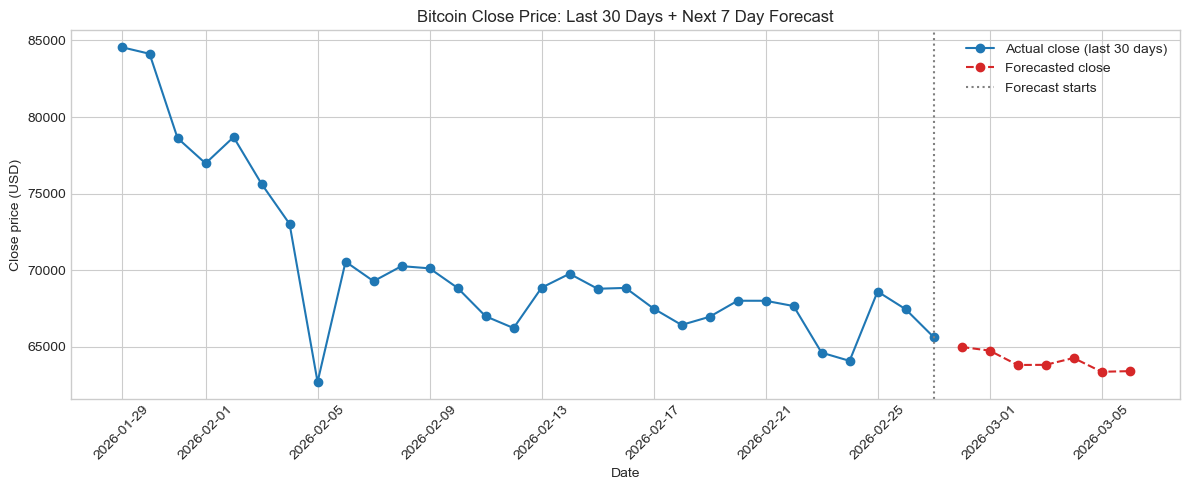

In [9]:

# Build a real future forecast from the last available sequence in the dataset
recent_scaled_window = scaled_series[-sequence_length:].reshape(1, sequence_length, 1)
recent_window_tensor = torch.tensor(recent_scaled_window, dtype=torch.float32).to(device)

main_lstm.eval()
with torch.no_grad():
    future_scaled = main_lstm(recent_window_tensor).cpu().numpy()

future_prices = inverse_close(future_scaled)[0]
last_30_actual = btc.tail(30).copy()
future_dates = pd.date_range(btc['date'].iloc[-1] + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

print('Predicted next close prices:')
forecast_table = pd.DataFrame({'date': future_dates, 'predicted_close': future_prices})
display(forecast_table.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(last_30_actual['date'], last_30_actual['close'], marker='o', label='Actual close (last 30 days)')
ax.plot(future_dates, future_prices, marker='o', linestyle='--', color='tab:red', label='Forecasted close')
ax.axvline(last_30_actual['date'].iloc[-1], color='gray', linestyle=':', label='Forecast starts')
ax.set_title(f'Bitcoin Close Price: Last 30 Days + Next {forecast_horizon} Day Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Close price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Part 7 - Architecture Comparison (1%)

I compare the LSTM against a simpler **feed-forward MLP baseline** trained on the same rolling windows.

### Why this comparison is meaningful
- The **MLP** sees the same past close prices but has **no recurrent memory**.
- The **LSTM** is designed for ordered sequence modeling and can learn temporal dynamics more naturally.

If the LSTM performs better, that supports the claim that sequential inductive bias matters for this forecasting task.


In [10]:

comparison_config = TrainingConfig(
    hidden_size=64,
    num_layers=2,
    dropout=0.2,
    learning_rate=1e-3,
    weight_decay=1e-5,
    epochs=20,
    patience=5,
)

comparison_window_data, comparison_masks, comparison_datasets, comparison_loaders = create_loaders(
    seq_len=sequence_length,
    horizon=forecast_horizon,
    batch_size=batch_size,
)

mlp_model = MLPForecaster(sequence_length=sequence_length, horizon=forecast_horizon, hidden_dim=128).to(device)
mlp_history = train_model(mlp_model, comparison_loaders, comparison_config)
mlp_test_metrics = evaluate_model(mlp_model, comparison_loaders['test'], nn.MSELoss())

comparison_table = pd.DataFrame([
    {
        'model': 'LSTM',
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_mape_percent': test_metrics['mape'],
    },
    {
        'model': 'MLP baseline',
        'test_rmse': mlp_test_metrics['rmse'],
        'test_mae': mlp_test_metrics['mae'],
        'test_mape_percent': mlp_test_metrics['mape'],
    },
])

print('Architecture comparison on the test split:')
display(comparison_table.round(3))



Epoch 01 | train_loss=0.025501 | val_loss=0.008122 | val_rmse=6073.06
Epoch 05 | train_loss=0.002052 | val_loss=0.003454 | val_rmse=3960.25
Epoch 10 | train_loss=0.001556 | val_loss=0.002275 | val_rmse=3213.89
Epoch 15 | train_loss=0.001467 | val_loss=0.001670 | val_rmse=2753.87
Early stopping triggered at epoch 19.
Architecture comparison on the test split:


,model,test_rmse,test_mae,test_mape_percent
0,LSTM,16937.862,14016.049,14.090
1,MLP baseline,6804.589,5452.184,5.962


The lower-RMSE model on the test set is: MLP baseline.


## Submission Checklist
- All code runs in **Jupyter Notebook** using the **`mlhub`** kernel.
- The selected task is **Part 2 - Option B: Time-Series Prediction**.
- The model predicts **Bitcoin daily closing prices** from historical close-price windows.
- `forecast_horizon` is treated as a configurable hyperparameter.
- Training, validation, and test results are reported.
- A controlled experiment is included.
- A comparison with another architecture is included.
- The notebook includes a final plot of the **last 30 true days** followed by the **future forecast**.
